# 01 — One Sample, One Estimate

**Lesson:** $\bar{x}$ is a random variable — same process, different samples, different estimates.

This notebook answers: *if I draw two different samples from the same return-generating process, will they give the same mean?* (Spoiler: no.)

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TRUE_MU = 0.04       # True daily mean of the process (%)
TRUE_SIGMA = 1.2     # True daily volatility of the process (%)
N_DAYS = 252         # Number of daily returns per sample
RANDOM_SEED = 42     # For reproducibility
TICKER = "SPY"       # Ticker for real data comparison
START_DATE = "2018-01-01"
END_DATE = "2025-12-31"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "../..")

from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

# Fix the random seed so the notebook is reproducible
rng = np.random.default_rng(RANDOM_SEED)

---

## Part A: Synthetic data — where we know the truth

We set up a return-generating process with a known true mean ($\mu = 0.04\%$ daily). Then we draw two samples from it. If $\bar{x}$ were a fixed number, both samples would give the same estimate. Let's see what actually happens.

### Sample 1

Draw 252 daily returns from a normal distribution with our true parameters. This is one possible year of data.

In [3]:
# Draw one sample of daily returns from the true process
sample1_returns = rng.normal(loc=TRUE_MU, scale=TRUE_SIGMA, size=N_DAYS)

# Compute the sample mean - this is our estimate of mu
sample1_mean = np.mean(sample1_returns)

print(f"Sample 1: {N_DAYS} daily returns drawn from N({TRUE_MU}%, {TRUE_SIGMA}%\u00b2)")
print(f"  Estimated mean (x\u0304): {sample1_mean:.4f}%")
print(f"  True mean (\u03bc):      {TRUE_MU:.2f}%")
print(f"  Difference:            {abs(sample1_mean - TRUE_MU):.4f}%")
print()
print("\u2192 The estimate is close to the truth, but not exact.")
print("\u2192 This difference is not a mistake - it is sampling error, and it is unavoidable.")

Sample 1: 252 daily returns drawn from N(0.04%, 1.2%²)
  Estimated mean (x̄): -0.0180%
  True mean (μ):      0.04%
  Difference:            0.0580%

→ The estimate is close to the truth, but not exact.
→ This difference is not a mistake - it is sampling error, and it is unavoidable.


### Sample 2

Now draw a **second, independent** sample from exactly the same process. Same $\mu$, same $\sigma$, same $n$.

In [4]:
# Draw a second independent sample from the same true process
sample2_returns = rng.normal(loc=TRUE_MU, scale=TRUE_SIGMA, size=N_DAYS)

# Compute its mean
sample2_mean = np.mean(sample2_returns)

print(f"Sample 1 mean: {sample1_mean:.4f}%")
print(f"Sample 2 mean: {sample2_mean:.4f}%")
print(f"True mean (\u03bc):  {TRUE_MU:.2f}%")
print()
print("\u2192 Same process. Same sample size. Different answer.")
print("\u2192 The sample mean is a random variable - its value depends on which returns happen to land in the sample.")

Sample 1 mean: -0.0180%
Sample 2 mean: 0.0670%
True mean (μ):  0.04%

→ Same process. Same sample size. Different answer.
→ The sample mean is a random variable - its value depends on which returns happen to land in the sample.


### Visual: both samples side by side

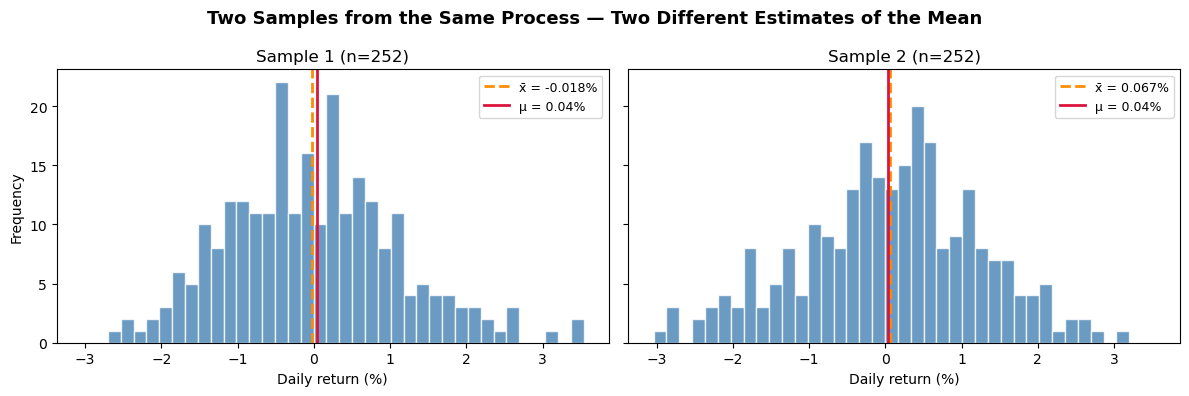

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)

# Common bins so the histograms are directly comparable
all_returns = np.concatenate([sample1_returns, sample2_returns])
bins = np.linspace(all_returns.min(), all_returns.max(), 40)

# Sample 1
axes[0].hist(sample1_returns, bins=bins, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(sample1_mean, color="darkorange", linewidth=2, linestyle="--",
                label=f"x\u0304 = {sample1_mean:.3f}%")
axes[0].axvline(TRUE_MU, color="crimson", linewidth=2, label=f"\u03bc = {TRUE_MU:.2f}%")
axes[0].set_title(f"Sample 1 (n={N_DAYS})")
axes[0].set_xlabel("Daily return (%)")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=9)

# Sample 2
axes[1].hist(sample2_returns, bins=bins, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(sample2_mean, color="darkorange", linewidth=2, linestyle="--",
                label=f"x\u0304 = {sample2_mean:.3f}%")
axes[1].axvline(TRUE_MU, color="crimson", linewidth=2, label=f"\u03bc = {TRUE_MU:.2f}%")
axes[1].set_title(f"Sample 2 (n={N_DAYS})")
axes[1].set_xlabel("Daily return (%)")
axes[1].legend(fontsize=9)

fig.suptitle("Two Samples from the Same Process — Two Different Estimates of the Mean",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaway:** Both histograms look broadly similar — they come from the same process. But the estimated mean (orange dashed line) is in a different place each time. Neither is *wrong* — they are both legitimate estimates — but they differ because $\bar{x}$ is a random variable. If we drew a third sample, we would get a third answer.

---

## Part B: Real SPY data — where we don't know the truth

The synthetic example used a normal distribution with a known $\mu$. In reality, we don't know the true mean. But we can still see the same phenomenon: different windows of real data give different estimates.

In [6]:
print(f"Loading {TICKER} data from {START_DATE} to {END_DATE}...")
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
spy_returns = prepare_returns(prices)

print(f"Observations: {len(spy_returns)}")
print(f"Date range: {spy_returns.index[0].date()} to {spy_returns.index[-1].date()}")
print(f"Overall mean daily return: {spy_returns.mean():.4f}%")
print(f"Overall std daily return:  {spy_returns.std():.4f}%")

Loading SPY data from 2018-01-01 to 2025-12-31...


Prepared 2009 daily returns (2018-01-03 to 2025-12-30) from 2010 price observations.
Observations: 2009
Date range: 2018-01-03 to 2025-12-30
Overall mean daily return: 0.0006%
Overall std daily return:  0.0123%


### Two non-overlapping windows

Pick two completely separate 252-day periods. These are like two independent "samples" from the market's return-generating process — except the process itself may have changed between them.

In [7]:
# Take two non-overlapping windows of N_DAYS each
window1_returns = spy_returns.iloc[:N_DAYS]        # first 252 days
window2_returns = spy_returns.iloc[-N_DAYS:]       # last 252 days

window1_mean = np.mean(window1_returns)
window2_mean = np.mean(window2_returns)

print(f"Window 1: {window1_returns.index[0].date()} \u2192 {window1_returns.index[-1].date()}")
print(f"  Mean daily return: {window1_mean:.4f}%")
print()
print(f"Window 2: {window2_returns.index[0].date()} \u2192 {window2_returns.index[-1].date()}")
print(f"  Mean daily return: {window2_mean:.4f}%")
print()
difference = abs(window1_mean - window2_mean)
print(f"Absolute difference between the two estimates: {difference:.4f}%")
print(f"  \u2192 Annualised: {difference * 252:.2f}%")
print()
print("\u2192 Same asset. Same window length. Radically different estimated mean.")
print("\u2192 This is NOT just a synthetic curiosity - it is your actual estimation problem.")

Window 1: 2018-01-03 → 2019-01-03
  Mean daily return: -0.0002%

Window 2: 2024-12-27 → 2025-12-30
  Mean daily return: 0.0006%

Absolute difference between the two estimates: 0.0009%
  → Annualised: 0.23%

→ Same asset. Same window length. Radically different estimated mean.
→ This is NOT just a synthetic curiosity - it is your actual estimation problem.


### Visual: two real-world windows side by side

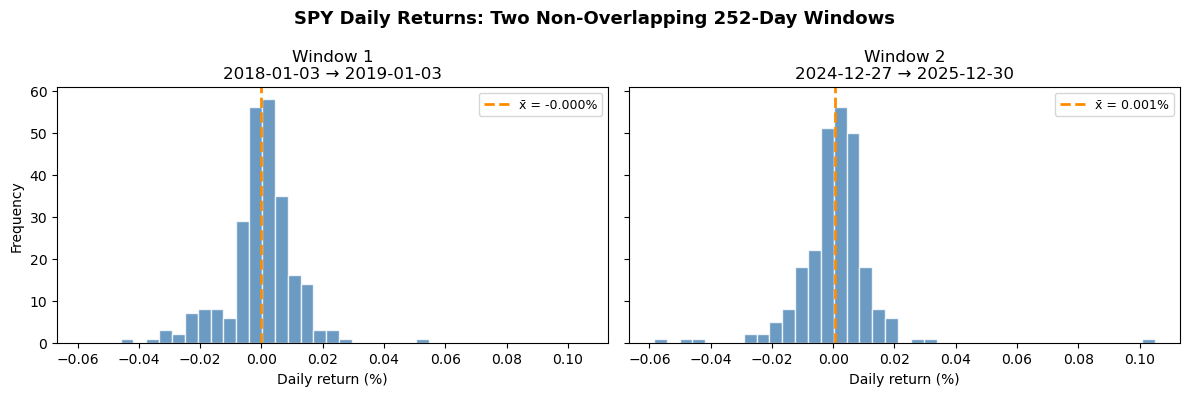

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Use consistent bins across both windows for fair comparison
all_spy = np.concatenate([window1_returns.values, window2_returns.values])
bins = np.linspace(all_spy.min(), all_spy.max(), 40)

# Window 1
axes[0].hist(window1_returns, bins=bins, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(window1_mean, color="darkorange", linewidth=2, linestyle="--",
                label=f"x\u0304 = {window1_mean:.3f}%")
axes[0].set_title(f"Window 1\n{window1_returns.index[0].date()} \u2192 {window1_returns.index[-1].date()}")
axes[0].set_xlabel("Daily return (%)")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=9)

# Window 2
axes[1].hist(window2_returns, bins=bins, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(window2_mean, color="darkorange", linewidth=2, linestyle="--",
                label=f"x\u0304 = {window2_mean:.3f}%")
axes[1].set_title(f"Window 2\n{window2_returns.index[0].date()} \u2192 {window2_returns.index[-1].date()}")
axes[1].set_xlabel("Daily return (%)")
axes[1].legend(fontsize=9)

fig.suptitle(f"{TICKER} Daily Returns: Two Non-Overlapping {N_DAYS}-Day Windows",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaway:** The two histograms don't just have different means — they have different *shapes*. Real markets go through different regimes. The first window and last window captured different economic environments, different volatility levels, different tail behaviour. The sample mean bounces around both because of sampling variability (the synthetic case) AND because the underlying process changes (the real-world complication).

---

## Key insight

**The sample mean $\bar{x}$ is a random variable.** Different samples from the same process give different estimates. This is not a bug in the calculation — it is a mathematical fact about working with finite data. The variation is real, and it is the starting point for everything else in statistics: standard errors, confidence intervals, hypothesis tests. They all exist *because* $\bar{x}$ bounces around from sample to sample.

Next: [02 — The Sampling Distribution](./002_the-sampling-distribution.ipynb) — if we draw thousands of samples, what pattern emerges?